<h1 style="font-family: 'poppins'; font-weight: bold; color: Green;">👨‍💻Author: SOBIA ALAMGIR</h1>

[![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/sobiahashmi) 
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-blue?style=for-the-badge&logo=kaggle)](https://www.linkedin.com/in/sobia-alamgir-a027b939/) 
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/sobia-alamgir-a027b939/)

<a id="13"></a>
<h1 style="background-color:#435420;font-family:newtimeroman;font-size:300%;text-align:center;border-radius: 15px 50px;color:#FF9900;">Binary Prediction Rainfall</h1>
<figcaption style="text-align: center;">
    <strong>
    </strong>
</figcaption>

## Step-01 Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, minmax_scale
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score

## Step-02 Import Dataset

In [6]:
df_train = pd.read_csv('train.csv')
display(df_train.head())

print("Shape of the Train dataset: ", df_train.shape)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


Shape of the Train dataset:  (2190, 13)


In [7]:
df_test = pd.read_csv('test.csv')
display(df_test.head())
print("Shape of the Test dataset: ", df_test.shape)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


Shape of the Test dataset:  (730, 12)


## Step-03 Data Preprocessing

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [9]:
df_train.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [10]:
df_test.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

In [11]:
df_test['winddirection'] = df_test['winddirection'].fillna(df_test['winddirection'].mean())

In [12]:
df_test.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [13]:
df_train.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [14]:
df_train.corr()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
id,1.000000,0.153065,-0.008235,0.012590,0.014307,0.018708,0.006797,-0.029042,0.002226,-0.003022,-0.004223,0.020167,0.033674
day,0.153065,1.000000,0.005337,0.146294,0.153590,0.161475,0.137929,-0.074048,-0.048175,0.060936,0.024800,-0.000199,-0.000462
pressure,-0.008235,0.005337,1.000000,-0.800499,-0.816531,-0.814453,-0.817008,-0.119949,0.098600,-0.257163,-0.643293,0.266012,-0.049886
maxtemp,0.012590,0.146294,-0.800499,1.000000,0.982932,0.965529,0.906703,-0.072615,-0.289047,0.452387,0.662235,-0.354168,-0.079304
temparature,0.014307,0.153590,-0.816531,0.982932,1.000000,0.987150,0.933617,-0.025016,-0.249355,0.414019,0.668963,-0.342262,-0.049660
mintemp,0.018708,0.161475,-0.814453,0.965529,0.987150,1.000000,0.941342,0.009891,-0.219399,0.379497,0.663828,-0.328871,-0.026841
dewpoint,0.006797,0.137929,-0.817008,0.906703,0.933617,0.941342,1.000000,0.153390,-0.088446,0.249676,0.643073,-0.312179,0.081965
humidity,-0.029042,-0.074048,-0.119949,-0.072615,-0.025016,0.009891,0.153390,1.000000,0.584854,-0.541592,-0.012430,0.062285,0.454213
cloud,0.002226,-0.048175,0.098600,-0.289047,-0.249355,-0.219399,-0.088446,0.584854,1.000000,-0.805128,-0.127087,0.184698,0.641191
sunshine,-0.003022,0.060936,-0.257163,0.452387,0.414019,0.379497,0.249676,-0.541592,-0.805128,1.000000,0.272235,-0.241752,-0.555287


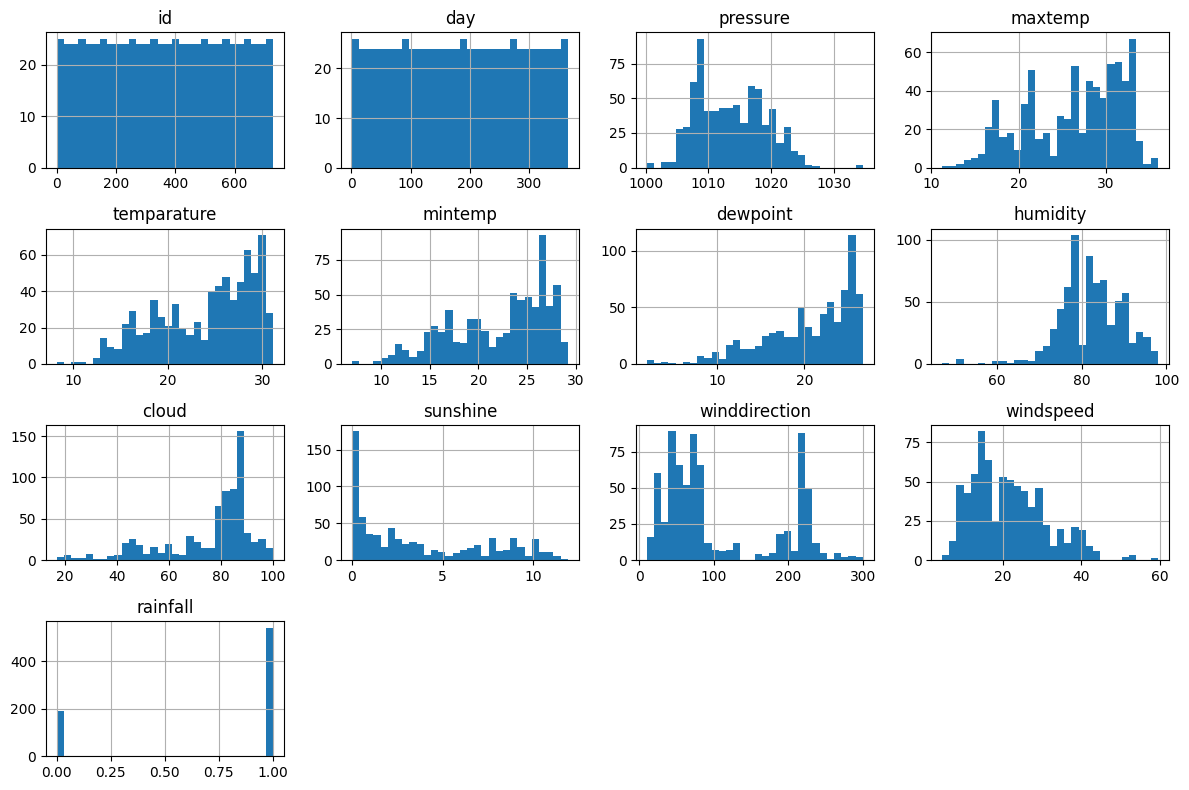

In [46]:
df_train.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

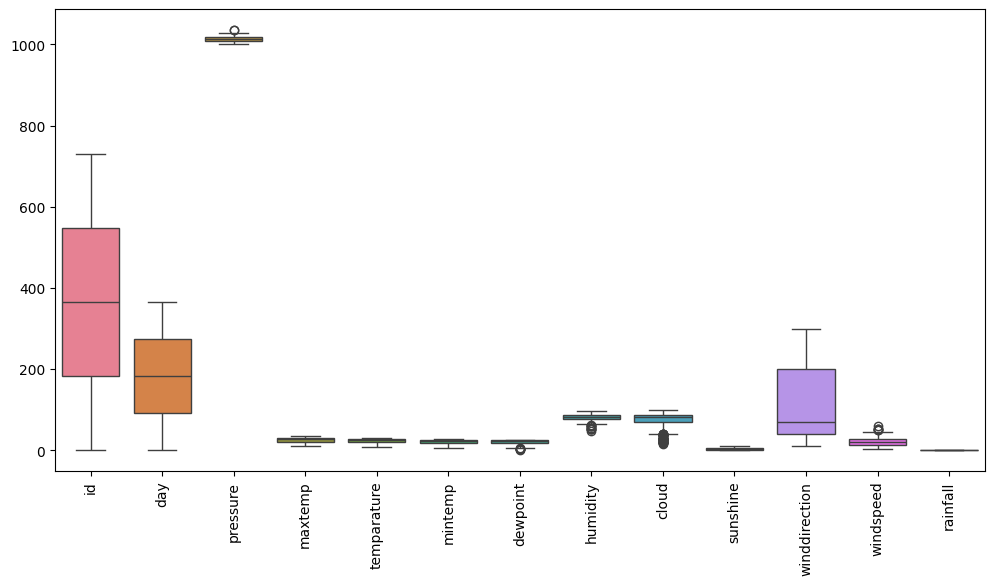

In [47]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train)
plt.xticks(rotation=90)
plt.show()

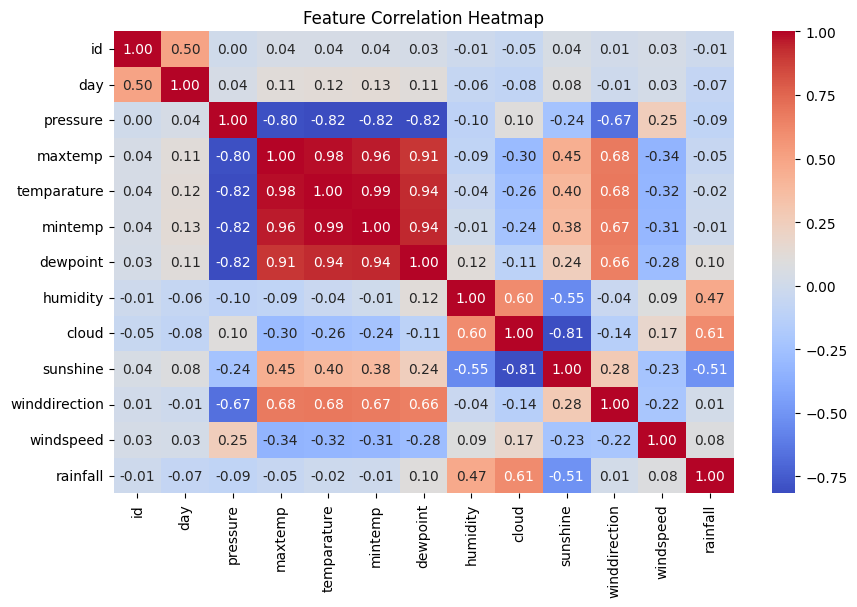

In [48]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


## Step-04 Split the data in X and y

In [16]:
df_train.shape

(2190, 13)

In [17]:
df_train.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall'],
      dtype='object')

In [18]:
X = df_train.drop(['rainfall'], axis = 1)
y = df_train['rainfall']

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1752, 12), (438, 12), (1752,), (438,))

## Step-05 Model Selection

### 1. Extream Gradient Boosting

**Extream Gragient Boosting:** is a machine learning algorithm based on gradient boosting that improves predictive accuracy and speed. It builds multiple decision trees sequentially, where each tree corrects the errors of the previous one, making it highly efficient for classification and regression tasks.

- It builds multiple decision trees sequentially 📈.
- Each new tree fixes mistakes of the previous one.
- Like learning from past failures to get better

***Boosting: Sequentially trains weak models, where each model corrects the errors of the previous one, giving higher weights to misclassified instances, improving overall accuracy. Example: XGBoost.***

In [20]:
model_XGBClassifier = XGBClassifier()
model_XGBClassifier.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### 2. Extream Gradient Boosting with Hyperparameters

In [21]:
model_xg = XGBClassifier()

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=model_xg,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    cv=5
)

In [22]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [100, 300, 500],
                         'reg_alpha': [0, 0.01, 0.1],
                         'reg_lambda': [0.1, 1, 10],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='accuracy')

In [23]:
print("Best Parameters:",grid_search.best_params_)
print("Best Score:",grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': 0.6}
Best Score: 0.8772910052910052


In [25]:
model_xg_hp = XGBClassifier(colsample_bytree= 0.8, gamma= 0.2, learning_rate= 0.01, max_depth= 5, min_child_weight= 5, n_estimators= 500, reg_alpha= 0.1, reg_lambda= 10, subsample= 0.6)

In [34]:
model_xg_hp.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### 3. Random Forest

**Random Forest** is an ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting. 
- bagging-based ensemble method
- High accuracy, robust to overfitting, and works well with both numerical & categorical data.

***Bagging (Bootstrap Aggregating): Trains multiple independent models on randomly bootstrapped subsets of data and averages their predictions to reduce variance and overfitting. Example: Random Forest.***

In [30]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train,y_train)

RandomForestClassifier()

### 4. Random Forest with Hyperparameters

In [49]:
%%time
model_rf_hp = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],  # Number of trees
    'max_depth': [10, 20, None],  # Tree depth (None = fully grown trees)
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2'],  # Feature selection for each tree
    'bootstrap': [True, False]  # Bootstrapping (True for bagging)
}

grid_search = GridSearchCV(
    estimator=model_rf_hp,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5
)

grid_search.fit(X_train, y_train) 

CPU times: total: 19.3 s
Wall time: 16min 30s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 300, 500]},
             scoring='roc_auc')

In [50]:
print("Best Parameters:",grid_search.best_params_)
print("Best Score:",grid_search.best_score_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
Best Score: 0.8988783670377277


In [52]:
model_rf_hp = RandomForestClassifier(bootstrap= True, max_depth= 10, max_features= 'sqrt', min_samples_leaf = 2, min_samples_split= 2, n_estimators= 500)
model_rf_hp = model_rf_hp.fit(X_train, y_train)

### 5. SVM

In [59]:
model_svm = SVC()
model_svm.fit(X_train,y_train)

SVC()

### 6. Logistic Regression

In [65]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

c:\Users\Sobia Alamgir\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### 7. Gradient Boosting Classifier

In [78]:
model_gbc = GradientBoostingClassifier()
model_gbc.fit(X_train, y_train)

GradientBoostingClassifier()

### 7. Light GBM

In [23]:
model_lightGBM = LGBMClassifier(random_state=42)
model_lightGBM.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1331, number of negative: 421
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 1752, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.759703 -> initscore=1.151053
[LightGBM] [Info] Start training from score 1.151053


LGBMClassifier(random_state=42)

### 8. Cat Boost 

In [24]:
model_catBoost = CatBoostClassifier(random_state=42)
model_catBoost.fit(X_train, y_train)

Learning rate set to 0.01309
0:	learn: 0.6819965	total: 22.2ms	remaining: 22.2s
1:	learn: 0.6703024	total: 75.7ms	remaining: 37.8s
2:	learn: 0.6592275	total: 112ms	remaining: 37.3s
3:	learn: 0.6484551	total: 127ms	remaining: 31.5s
4:	learn: 0.6373769	total: 136ms	remaining: 27.1s
5:	learn: 0.6288844	total: 146ms	remaining: 24.2s
6:	learn: 0.6191769	total: 156ms	remaining: 22.1s
7:	learn: 0.6112991	total: 165ms	remaining: 20.4s
8:	learn: 0.6013986	total: 174ms	remaining: 19.1s
9:	learn: 0.5920167	total: 182ms	remaining: 18s
10:	learn: 0.5848492	total: 192ms	remaining: 17.2s
11:	learn: 0.5770722	total: 205ms	remaining: 16.9s
12:	learn: 0.5687422	total: 220ms	remaining: 16.7s
13:	learn: 0.5600885	total: 237ms	remaining: 16.7s
14:	learn: 0.5526770	total: 249ms	remaining: 16.3s
15:	learn: 0.5455068	total: 256ms	remaining: 15.7s
16:	learn: 0.5386224	total: 262ms	remaining: 15.2s
17:	learn: 0.5318220	total: 270ms	remaining: 14.7s
18:	learn: 0.5257361	total: 277ms	remaining: 14.3s
19:	learn: 0

In [41]:
ridge_clf = RidgeClassifier(alpha=8.84, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=None, solver='auto',
                tol=0.0001)
ridge_clf.fit(X_train, y_train)

RidgeClassifier(alpha=8.84)

## Step-06 Model Prediction

In [25]:
model_xg_pred = model_XGBClassifier.predict(df_test)
model_rf_pred = model_rf.predict(df_test)
model_xg_hp_pred = model_xg_hp.predict(df_test)
model_rf_hp_pred = model_rf_hp.predict(df_test)
model_svm_pred = model_svm.predict(df_test)
model_lr_pred = model_lr.predict(df_test)
model_gbc_pred = model_gbc.predict(df_test)

NameError: name 'model_XGBClassifier' is not defined

In [42]:
model_lightGBM_pred = model_lightGBM.predict(df_test)
model_catBoost_pred = model_catBoost.predict(df_test)
model_ridge_pred = ridge_clf.predict(df_test)

## Step-07 Model Evaluation

In [27]:
display(y_test.shape,df_test.shape)

(438,)

(730, 12)

In [ ]:
df_train = df_train.head(730)

In [80]:

print("_____XGBClassifier Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_xg_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_xg_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____XGBClassifier Prediction with Hyperparameters_____")
Accuracy = accuracy_score(df_train['rainfall'], model_xg_hp_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_xg_hp_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____Random Forestr Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_rf_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_rf_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____Random Forestr Prediction with Hyperparameters_____")
Accuracy = accuracy_score(df_train['rainfall'], model_rf_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_rf_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____Support Vector Machine Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_svm_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_svm_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____Logistic Regression Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_lr_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_lr_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____Gradient Boosting Classifier Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_gbc_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_gbc_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

_____XGBClassifier Prediction_____
Accuracy: 0.68
ROC-AUC Score: 0.54
_____XGBClassifier Prediction with Hyperparameters_____
Accuracy: 0.68
ROC-AUC Score: 0.56
_____Random Forestr Prediction_____
Accuracy: 0.68
ROC-AUC Score: 0.55
_____Random Forestr Prediction with Hyperparameters_____
Accuracy: 0.68
ROC-AUC Score: 0.55
_____Support Vector Machine Prediction_____
Accuracy: 0.74
ROC-AUC Score: 0.50
_____Logistic Regression Prediction_____
Accuracy: 0.69
ROC-AUC Score: 0.53
_____Gradient Boosting Classifier Prediction_____
Accuracy: 0.68
ROC-AUC Score: 0.54


In [43]:
print("_____LightGBM Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_lightGBM_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_lightGBM_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____CatBoost Prediction_____")
Accuracy = accuracy_score(df_train['rainfall'], model_catBoost_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_catBoost_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

print("_____Ridge Classifier_____")
Accuracy = accuracy_score(df_train['rainfall'], model_ridge_pred)
print(f"Accuracy: {Accuracy:.2f}")
auc_score = roc_auc_score(df_train['rainfall'], model_ridge_pred)
print(f"ROC-AUC Score: {auc_score:.2f}")

_____LightGBM Prediction_____
Accuracy: 0.70
ROC-AUC Score: 0.56
_____CatBoost Prediction_____
Accuracy: 0.69
ROC-AUC Score: 0.56
_____Ridge Classifier_____
Accuracy: 0.68
ROC-AUC Score: 0.54


## Step-08 Data Visualization

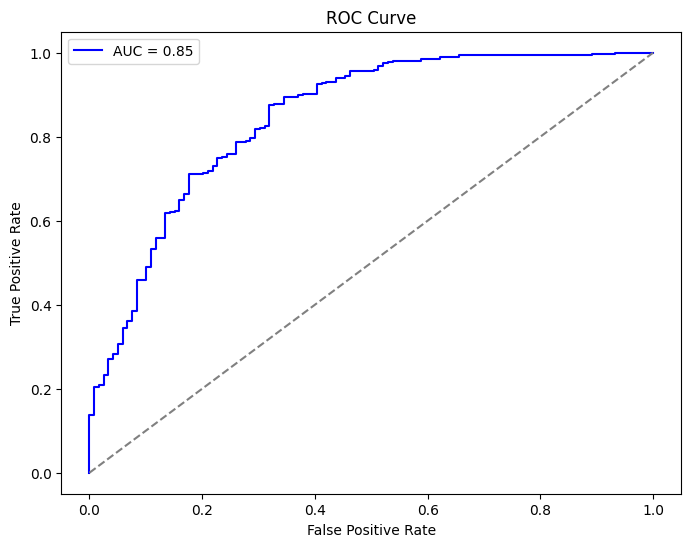

In [50]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = model_lightGBM.predict_proba(X_test)[:, 1]  # Get probabilities
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step-09 Create Dataframes

In [ ]:
df_xg = pd.DataFrame({"id":df_test["id"], "rainfall":model_xg_pred})
df_xg.head()

df_rf = pd.DataFrame({"id":df_test["id"], "rainfall":model_rf_pred})
df_rf.head()

df_xg_hp = pd.DataFrame({"id":df_test["id"], "rainfall":model_xg_hp_pred})
df_xg_hp.head()

df_rf_hp = pd.DataFrame({"id":df_test["id"], "rainfall":model_rf_hp_pred})
df_rf_hp.head()

df_svm = pd.DataFrame({"id":df_test["id"], "rainfall":model_svm_pred})
df_svm.head()

df_lr = pd.DataFrame({"id":df_test["id"], "rainfall":model_lr_pred})
df_lr.head()

df_gbc = pd.DataFrame({"id":df_test["id"], "rainfall":model_gbc_pred})
df_gbc.head()

In [44]:
df_lightGBM = pd.DataFrame({"id":df_test["id"], "rainfall":model_lightGBM_pred})
df_lightGBM.head()

df_catBoost = pd.DataFrame({"id":df_test["id"], "rainfall":model_catBoost_pred})
df_catBoost.head()

df_ridge = pd.DataFrame({"id":df_test["id"], "rainfall":model_ridge_pred})
df_ridge.head()

,id,rainfall
0,2190,1
1,2191,1
2,2192,1
3,2193,0
4,2194,0


## Step-10 Convert to csv

In [82]:
df_xg.to_csv("XGBClassifier_Prediction.csv", index = False)
df_rf.to_csv("RandomForest_Prediction.csv", index = False)
df_xg_hp.to_csv("XGB_Prediction_with_hp.csv", index = False)
df_rf_hp.to_csv("Random_Forest_with_hp.csv", index = False)
df_svm.to_csv("SVM_Prediction.csv", index = False)
df_lr.to_csv("Logistic_Regression_Prediction.csv", index = False)
df_gbc.to_csv("Gradient_Boosting_Prediction.csv", index = False)

In [45]:
df_lightGBM.to_csv("LightGBM_Prediction.csv", index = False)
df_catBoost.to_csv("CatBoost_Prediction.csv", index = False)
df_ridge.to_csv("Ridge_Prediction.csv", index = False)

<a id="13"></a>
<h1 style="background-color:#435420;font-family:newtimeroman;font-size:300%;text-align:center;border-radius: 15px 50px;color:#FF9900;">Thankyou</h1>
<figcaption style="text-align: center;">
    <strong>
    </strong>
</figcaption>